500 500


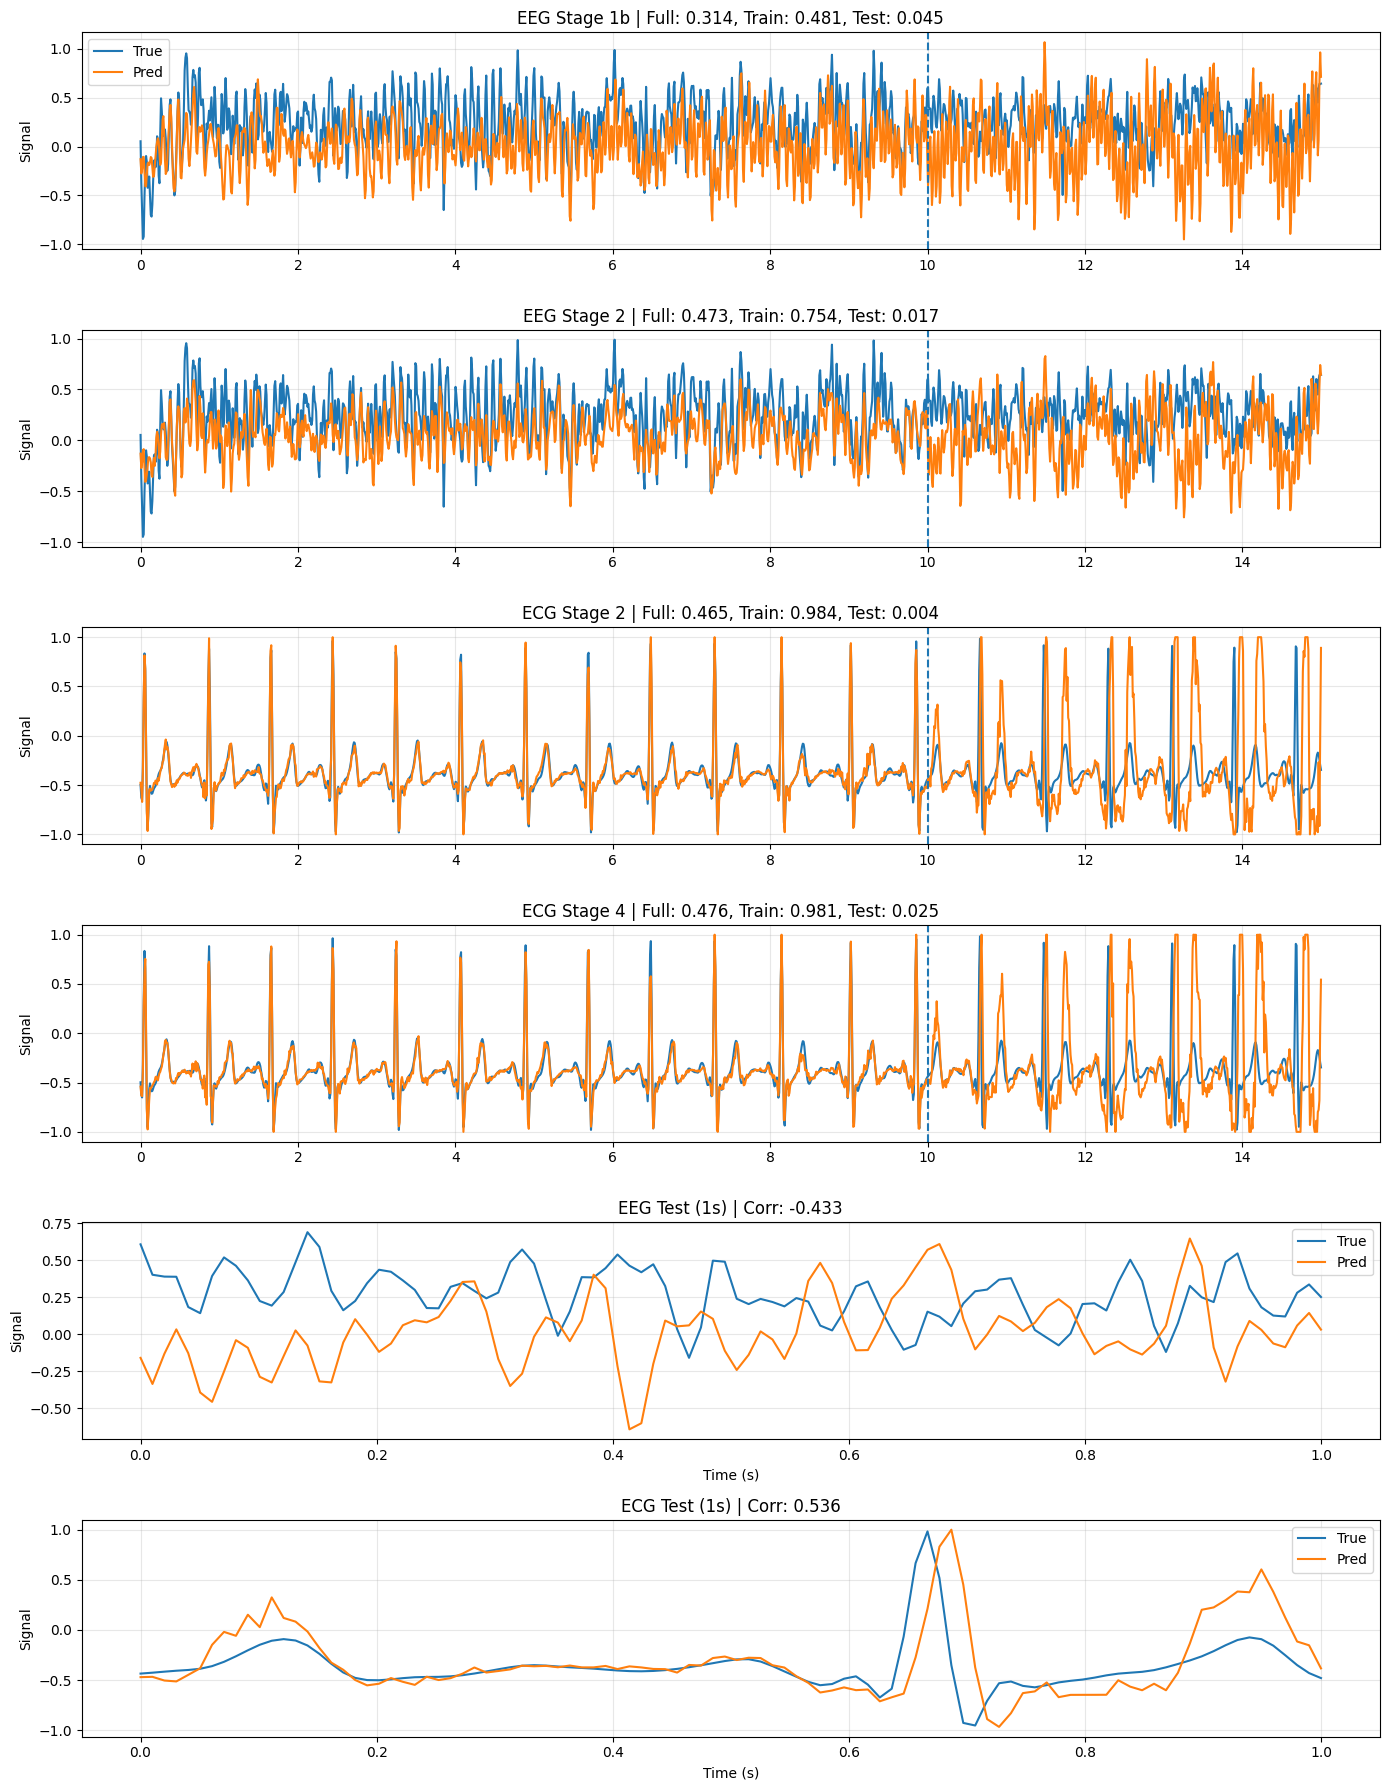

In [6]:
import numpy as np
import matplotlib.pyplot as plt

FS = 100  # sampling frequency


def compute_corr(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    return np.sum(x * y) / (np.sqrt(np.sum(x**2) * np.sum(y**2)) + 1e-8)


def load_all(region_dir, true_name, pred_name):
    return {
        "true_full": np.load(f"{region_dir}/{true_name}_full.npy"),
        "pred_full": np.load(f"{region_dir}/{pred_name}_full.npy"),
        "true_train": np.load(f"{region_dir}/{true_name}_train.npy"),
        "pred_train": np.load(f"{region_dir}/{pred_name}_train.npy"),
        "true_test": np.load(f"{region_dir}/{true_name}_test.npy"),
        "pred_test": np.load(f"{region_dir}/{pred_name}_test.npy"),
    }


def plot_all(region_dir):
    configs = [
        ("eeg_true", "eeg_stage1b", "EEG Stage 1b"),
        ("eeg_true", "eeg_stage2", "EEG Stage 2"),
        ("ecg_true", "ecg_stage2", "ECG Stage 2"),
        ("ecg_true", "ecg_stage4", "ECG Stage 4"),
    ]

    fig, axes = plt.subplots(6, 1, figsize=(14, 18))

    # -------- FULL PLOTS (same as before) --------
    for i, (true_name, pred_name, title) in enumerate(configs):
        data = load_all(region_dir, true_name, pred_name)

        true_full = data["true_full"]
        pred_full = data["pred_full"]
        true_train = data["true_train"]
        pred_train = data["pred_train"]
        true_test = data["true_test"]
        pred_test = data["pred_test"]

        # correlations
        corr_full = compute_corr(pred_full, true_full)
        corr_train = compute_corr(pred_train, true_train)
        corr_test = compute_corr(pred_test, true_test)

        # time
        T = len(true_full)
        t = np.linspace(0, T / FS, T)
        T_train = len(true_train)

        ax = axes[i]
        ax.plot(t, true_full, label="True")
        ax.plot(t, pred_full, label="Pred")

        ax.axvline(t[T_train], linestyle="--")

        ax.set_title(
            f"{title} | Full: {corr_full:.3f}, Train: {corr_train:.3f}, Test: {corr_test:.3f}"
        )
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)

        if i == 0:
            ax.legend()

    # -------- ZOOMED TEST PLOTS (1 second) --------
    zoom_configs = [
        ("eeg_true", "eeg_stage2", "EEG Test (1s)"),
        ("ecg_true", "ecg_stage4", "ECG Test (1s)"),
    ]
    print(len(true_test), len(pred_test))

    for j, (true_name, pred_name, title) in enumerate(zoom_configs):
        data = load_all(region_dir, true_name, pred_name)

        true_test = data["true_test"]
        pred_test = data["pred_test"]


        # first 1 second
        n = min(FS, len(true_test))
        t = np.linspace(0, n / FS, n)

        corr = compute_corr(pred_test[:n], true_test[:n])

        ax = axes[4 + j]
        ax.plot(t, true_test[:n], label="True")
        ax.plot(t, pred_test[:n], label="Pred")

        ax.set_title(f"{title} | Corr: {corr:.3f}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Run
region_dir = "/home/shobs/Desktop/DDP/multi_region_results/region_22"
plot_all(region_dir)

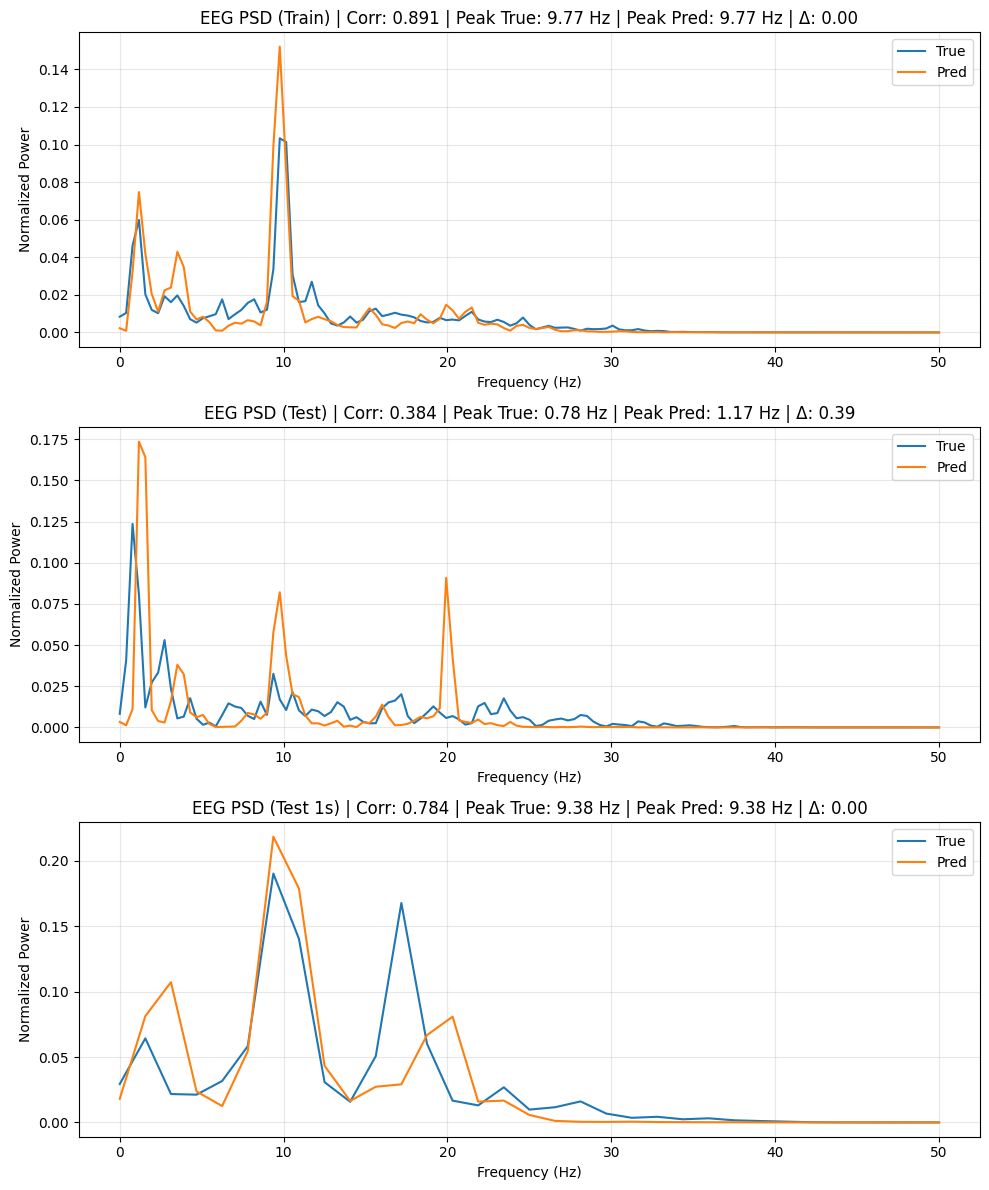

In [7]:
# ─────────────────────────────────────────────────────────────
# EEG PSD ANALYSIS (Train + Test)
# ─────────────────────────────────────────────────────────────

from scipy.signal import welch

def compute_psd(signal, fs=100):
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    return freqs, psd


def compute_psd_corr(psd1, psd2):
    psd1 = psd1 - np.mean(psd1)
    psd2 = psd2 - np.mean(psd2)
    return np.sum(psd1 * psd2) / (
        np.sqrt(np.sum(psd1**2) * np.sum(psd2**2)) + 1e-8
    )


def peak_frequency(freqs, psd):
    return freqs[np.argmax(psd)]


def plot_psd_eeg(region_dir):
    data = load_all(region_dir, "eeg_true", "eeg_stage2")

    splits = {
        "Train": (data["true_train"], data["pred_train"]),
        "Test":  (data["true_test"],  data["pred_test"]),
    }

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    # -------- FULL TRAIN + TEST PSD --------
    for i, (split_name, (true_sig, pred_sig)) in enumerate(splits.items()):
        f_true, psd_true = compute_psd(true_sig, FS)
        f_pred, psd_pred = compute_psd(pred_sig, FS)

        psd_true = psd_true / (psd_true.sum() + 1e-8)
        psd_pred = psd_pred / (psd_pred.sum() + 1e-8)

        psd_corr = compute_psd_corr(psd_true, psd_pred)

        peak_true = peak_frequency(f_true, psd_true)
        peak_pred = peak_frequency(f_pred, psd_pred)
        peak_err  = abs(peak_true - peak_pred)

        ax = axes[i]
        ax.plot(f_true, psd_true, label="True")
        ax.plot(f_pred, psd_pred, label="Pred")

        ax.set_title(
            f"EEG PSD ({split_name}) | Corr: {psd_corr:.3f} | "
            f"Peak True: {peak_true:.2f} Hz | Peak Pred: {peak_pred:.2f} Hz | Δ: {peak_err:.2f}"
        )
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Normalized Power")
        ax.grid(alpha=0.3)
        ax.legend()

    # -------- 1 SECOND TEST PSD --------
    true_test = data["true_test"]
    pred_test = data["pred_test"]

    n = min(FS, len(true_test))  # 1 second
    true_1s = true_test[:n]
    pred_1s = pred_test[:n]

    # IMPORTANT: adjust nperseg for short signal
    f_true, psd_true = welch(true_1s, fs=FS, nperseg=min(64, n))
    f_pred, psd_pred = welch(pred_1s, fs=FS, nperseg=min(64, n))

    psd_true = psd_true / (psd_true.sum() + 1e-8)
    psd_pred = psd_pred / (psd_pred.sum() + 1e-8)

    psd_corr = compute_psd_corr(psd_true, psd_pred)

    peak_true = peak_frequency(f_true, psd_true)
    peak_pred = peak_frequency(f_pred, psd_pred)
    peak_err  = abs(peak_true - peak_pred)

    ax = axes[2]
    ax.plot(f_true, psd_true, label="True")
    ax.plot(f_pred, psd_pred, label="Pred")

    ax.set_title(
        f"EEG PSD (Test 1s) | Corr: {psd_corr:.3f} | "
        f"Peak True: {peak_true:.2f} Hz | Peak Pred: {peak_pred:.2f} Hz | Δ: {peak_err:.2f}"
    )
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Normalized Power")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_psd_eeg(region_dir)

Region 8:
  Intrinsic corr = 0.0126
  EEG Test corr (1s) = -0.1724

Region 9:
  Intrinsic corr = -0.0441
  EEG Test corr (1s) = -0.0367

Region 10:
  Intrinsic corr = -0.0372
  EEG Test corr (1s) = -0.2608

Region 11:
  Intrinsic corr = 0.0418
  EEG Test corr (1s) = -0.3346

Region 12:
  Intrinsic corr = 0.1220
  EEG Test corr (1s) = 0.0479

Region 13:
  Intrinsic corr = -0.0306
  EEG Test corr (1s) = 0.3339

Region 14:
  Intrinsic corr = 0.0089
  EEG Test corr (1s) = -0.1590

Region 15:
  Intrinsic corr = 0.0006
  EEG Test corr (1s) = -0.2078

Region 16:
  Intrinsic corr = 0.0768
  EEG Test corr (1s) = -0.0546

Region 17:
  Intrinsic corr = 0.0352
  EEG Test corr (1s) = -0.1901

Region 18:
  Intrinsic corr = 0.0415
  EEG Test corr (1s) = -0.0660

Region 19:
  Intrinsic corr = 0.0236
  EEG Test corr (1s) = -0.0280

Region 20:
  Intrinsic corr = -0.0158
  EEG Test corr (1s) = 0.0918

Region 21:
  Intrinsic corr = 0.0068
  EEG Test corr (1s) = -0.2512

FINAL RESULT (EEG)
Intrinsic: [ 0.0

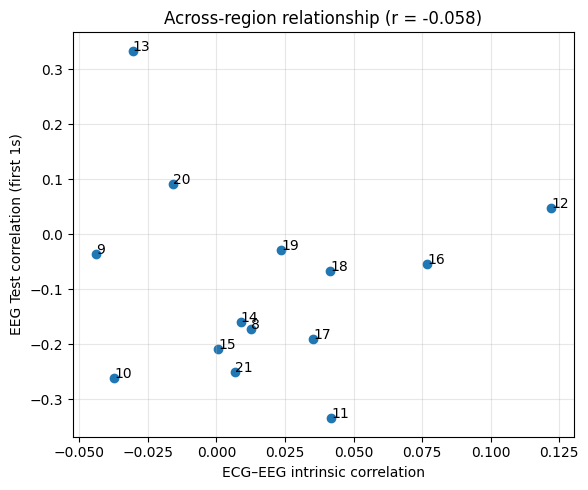

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

FS = 100  # sampling frequency


def compute_corr(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    return np.sum(x * y) / (np.sqrt(np.sum(x**2) * np.sum(y**2)) + 1e-8)


def load_all(region_dir, true_name, pred_name):
    return {
        "true_full": np.load(f"{region_dir}/{true_name}_full.npy"),
        "pred_full": np.load(f"{region_dir}/{pred_name}_full.npy"),
        "true_train": np.load(f"{region_dir}/{true_name}_train.npy"),
        "pred_train": np.load(f"{region_dir}/{pred_name}_train.npy"),
        "true_test": np.load(f"{region_dir}/{true_name}_test.npy"),
        "pred_test": np.load(f"{region_dir}/{pred_name}_test.npy"),
    }


def analyze_regions(base_dir, regions):
    intrinsic_corrs = []
    test_corrs_1s = []

    for r in regions:
        region_dir = f"{base_dir}/region_{r}"

        # ---- intrinsic ECG–EEG correlation (FULL) ----
        ecg = np.load(f"{region_dir}/ecg_true_full.npy")
        eeg = np.load(f"{region_dir}/eeg_true_full.npy")

        intrinsic_corr = compute_corr(ecg, eeg)

        # ---- EEG model performance (Stage 2, first 1s of test) ----
        data = load_all(region_dir, "eeg_true", "eeg_stage2")

        true_test = data["true_test"]
        pred_test = data["pred_test"]

        n = min(FS, len(true_test))  # 1 second = 100 samples
        test_corr = compute_corr(pred_test[:n], true_test[:n])

        intrinsic_corrs.append(intrinsic_corr)
        test_corrs_1s.append(test_corr)

        print(f"Region {r}:")
        print(f"  Intrinsic corr = {intrinsic_corr:.4f}")
        print(f"  EEG Test corr (1s) = {test_corr:.4f}")
        print("")

    intrinsic_corrs = np.array(intrinsic_corrs)
    test_corrs_1s = np.array(test_corrs_1s)

    # ---- relationship ----
    final_corr = compute_corr(intrinsic_corrs, test_corrs_1s)
    r_stat, p_val = pearsonr(intrinsic_corrs, test_corrs_1s)

    print("=====================================")
    print("FINAL RESULT (EEG)")
    print("=====================================")
    print("Intrinsic:", intrinsic_corrs)
    print("EEG Test (1s):", test_corrs_1s)
    print(f"Relationship corr = {final_corr:.4f}")
    print(f"Pearson r = {r_stat:.4f}, p = {p_val:.6f}")
    print("=====================================")

    return intrinsic_corrs, test_corrs_1s, final_corr


def plot_relationship(x, y, regions, r):
    plt.figure(figsize=(6, 5))

    plt.scatter(x, y)

    for i, region in enumerate(regions):
        plt.text(x[i], y[i], str(region))

    plt.xlabel("ECG–EEG intrinsic correlation")
    plt.ylabel("EEG Test correlation (first 1s)")
    plt.title(f"Across-region relationship (r = {r:.3f})")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    base_dir = "/home/shobs/Desktop/DDP/multi_region_results"
    regions = list(range(8, 22))

    x, y, r = analyze_regions(base_dir, regions)
    plot_relationship(x, y, regions, r)

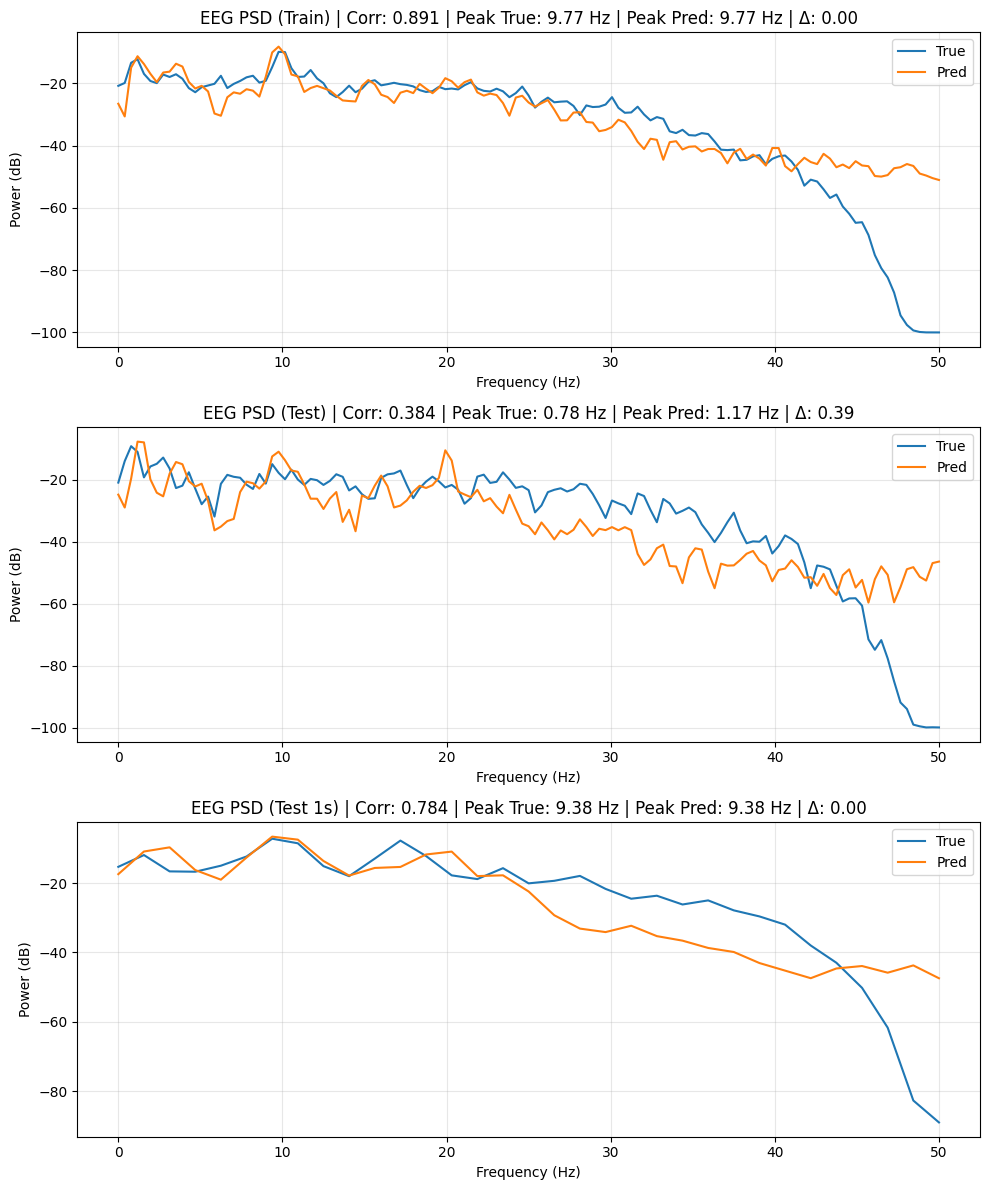

In [9]:
# ─────────────────────────────────────────────────────────────
# EEG PSD ANALYSIS (Train + Test) — LOG / dB SCALE
# ─────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

FS = 100  # sampling frequency


def compute_psd(signal, fs=100):
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    return freqs, psd


def compute_psd_corr(psd1, psd2):
    psd1 = psd1 - np.mean(psd1)
    psd2 = psd2 - np.mean(psd2)
    return np.sum(psd1 * psd2) / (
        np.sqrt(np.sum(psd1**2) * np.sum(psd2**2)) + 1e-8
    )


def peak_frequency(freqs, psd):
    return freqs[np.argmax(psd)]


def plot_psd_eeg(region_dir):
    data = load_all(region_dir, "eeg_true", "eeg_stage2")

    splits = {
        "Train": (data["true_train"], data["pred_train"]),
        "Test":  (data["true_test"],  data["pred_test"]),
    }

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    # -------- FULL TRAIN + TEST PSD --------
    for i, (split_name, (true_sig, pred_sig)) in enumerate(splits.items()):
        f_true, psd_true = compute_psd(true_sig, FS)
        f_pred, psd_pred = compute_psd(pred_sig, FS)

        # Normalize
        psd_true = psd_true / (psd_true.sum() + 1e-8)
        psd_pred = psd_pred / (psd_pred.sum() + 1e-8)

        # Metrics (computed in linear space)
        psd_corr = compute_psd_corr(psd_true, psd_pred)
        peak_true = peak_frequency(f_true, psd_true)
        peak_pred = peak_frequency(f_pred, psd_pred)
        peak_err  = abs(peak_true - peak_pred)

        # Convert to dB scale
        psd_true_db = 10 * np.log10(psd_true + 1e-10)
        psd_pred_db = 10 * np.log10(psd_pred + 1e-10)

        ax = axes[i]
        ax.plot(f_true, psd_true_db, label="True")
        ax.plot(f_pred, psd_pred_db, label="Pred")

        ax.set_title(
            f"EEG PSD ({split_name}) | Corr: {psd_corr:.3f} | "
            f"Peak True: {peak_true:.2f} Hz | Peak Pred: {peak_pred:.2f} Hz | Δ: {peak_err:.2f}"
        )
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power (dB)")
        ax.grid(alpha=0.3)
        ax.legend()

    # -------- 1 SECOND TEST PSD --------
    true_test = data["true_test"]
    pred_test = data["pred_test"]

    n = min(FS, len(true_test))  # 1 second
    true_1s = true_test[:n]
    pred_1s = pred_test[:n]

    f_true, psd_true = welch(true_1s, fs=FS, nperseg=min(64, n))
    f_pred, psd_pred = welch(pred_1s, fs=FS, nperseg=min(64, n))

    # Normalize
    psd_true = psd_true / (psd_true.sum() + 1e-8)
    psd_pred = psd_pred / (psd_pred.sum() + 1e-8)

    # Metrics
    psd_corr = compute_psd_corr(psd_true, psd_pred)
    peak_true = peak_frequency(f_true, psd_true)
    peak_pred = peak_frequency(f_pred, psd_pred)
    peak_err  = abs(peak_true - peak_pred)

    # Convert to dB
    psd_true_db = 10 * np.log10(psd_true + 1e-10)
    psd_pred_db = 10 * np.log10(psd_pred + 1e-10)

    ax = axes[2]
    ax.plot(f_true, psd_true_db, label="True")
    ax.plot(f_pred, psd_pred_db, label="Pred")

    ax.set_title(
        f"EEG PSD (Test 1s) | Corr: {psd_corr:.3f} | "
        f"Peak True: {peak_true:.2f} Hz | Peak Pred: {peak_pred:.2f} Hz | Δ: {peak_err:.2f}"
    )
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (dB)")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_psd_eeg(region_dir)

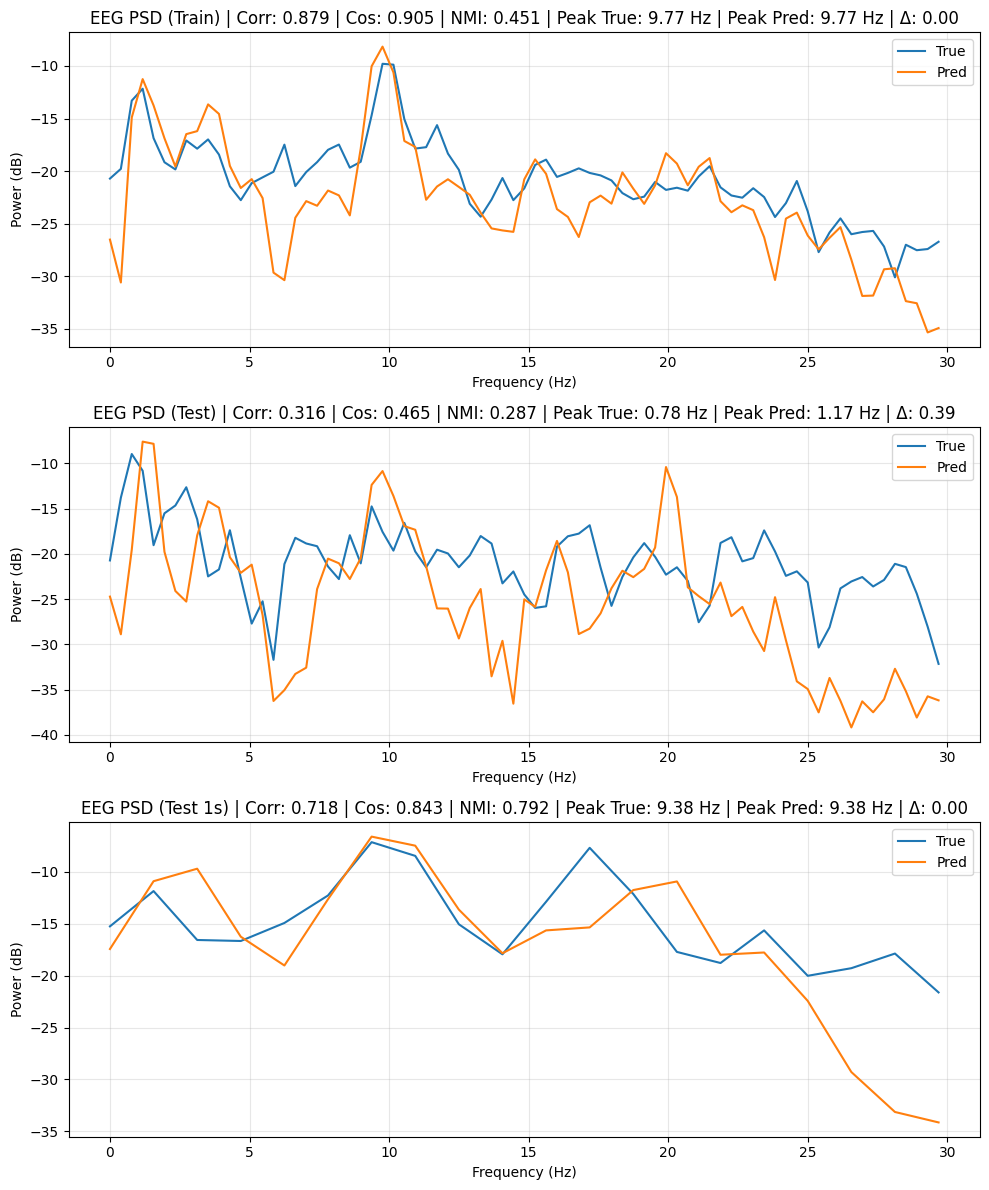

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

FS = 100  # sampling frequency


# -----------------------------
# PSD
# -----------------------------
def compute_psd(signal, fs=100):
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    return freqs, psd


def restrict_freq_range(freqs, psd, fmax=30):
    mask = freqs <= fmax
    return freqs[mask], psd[mask]


# -----------------------------
# Metrics
# -----------------------------
def compute_psd_corr(psd1, psd2):
    psd1 = psd1 - np.mean(psd1)
    psd2 = psd2 - np.mean(psd2)
    return np.sum(psd1 * psd2) / (
        np.sqrt(np.sum(psd1**2) * np.sum(psd2**2)) + 1e-8
    )


def compute_cosine_similarity(x, y):
    x = x.flatten()
    y = y.flatten()
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y) + 1e-8)


def compute_nmi(x, y, bins=30):
    x = x.flatten()
    y = y.flatten()

    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    joint_prob = joint_hist / (np.sum(joint_hist) + 1e-12)

    px = np.sum(joint_prob, axis=1)
    py = np.sum(joint_prob, axis=0)

    Hx = -np.sum(px * np.log(px + 1e-12))
    Hy = -np.sum(py * np.log(py + 1e-12))

    mi = 0.0
    for i in range(len(px)):
        for j in range(len(py)):
            if joint_prob[i, j] > 0:
                mi += joint_prob[i, j] * np.log(
                    joint_prob[i, j] / (px[i] * py[j] + 1e-12)
                )

    nmi = 2 * mi / (Hx + Hy + 1e-12)
    return nmi


# -----------------------------
# Peak frequency
# -----------------------------
def peak_frequency(freqs, psd):
    return freqs[np.argmax(psd)]


# -----------------------------
# Main Plot Function
# -----------------------------
def plot_psd_eeg(region_dir):
    data = load_all(region_dir, "eeg_true", "eeg_stage2")

    splits = {
        "Train": (data["true_train"], data["pred_train"]),
        "Test":  (data["true_test"],  data["pred_test"]),
    }

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    # -------- FULL TRAIN + TEST PSD --------
    for i, (split_name, (true_sig, pred_sig)) in enumerate(splits.items()):
        f_true, psd_true = compute_psd(true_sig, FS)
        f_pred, psd_pred = compute_psd(pred_sig, FS)

        # Restrict to 0–30 Hz
        f_true, psd_true = restrict_freq_range(f_true, psd_true)
        f_pred, psd_pred = restrict_freq_range(f_pred, psd_pred)

        # Normalize
        psd_true = psd_true / (psd_true.sum() + 1e-8)
        psd_pred = psd_pred / (psd_pred.sum() + 1e-8)

        # Metrics
        psd_corr = compute_psd_corr(psd_true, psd_pred)
        cos_sim  = compute_cosine_similarity(psd_true, psd_pred)
        nmi_score = compute_nmi(psd_true, psd_pred)

        peak_true = peak_frequency(f_true, psd_true)
        peak_pred = peak_frequency(f_pred, psd_pred)
        peak_err  = abs(peak_true - peak_pred)

        # Convert to dB
        psd_true_db = 10 * np.log10(psd_true + 1e-10)
        psd_pred_db = 10 * np.log10(psd_pred + 1e-10)

        ax = axes[i]
        ax.plot(f_true, psd_true_db, label="True")
        ax.plot(f_pred, psd_pred_db, label="Pred")

        ax.set_title(
            f"EEG PSD ({split_name}) | Corr: {psd_corr:.3f} | Cos: {cos_sim:.3f} | "
            f"NMI: {nmi_score:.3f} | Peak True: {peak_true:.2f} Hz | "
            f"Peak Pred: {peak_pred:.2f} Hz | Δ: {peak_err:.2f}"
        )
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power (dB)")
        ax.grid(alpha=0.3)
        ax.legend()

    # -------- 1 SECOND TEST PSD --------
    true_test = data["true_test"]
    pred_test = data["pred_test"]

    n = min(FS, len(true_test))
    true_1s = true_test[:n]
    pred_1s = pred_test[:n]

    f_true, psd_true = welch(true_1s, fs=FS, nperseg=min(64, n))
    f_pred, psd_pred = welch(pred_1s, fs=FS, nperseg=min(64, n))

    # Restrict to 0–30 Hz
    f_true, psd_true = restrict_freq_range(f_true, psd_true)
    f_pred, psd_pred = restrict_freq_range(f_pred, psd_pred)

    # Normalize
    psd_true = psd_true / (psd_true.sum() + 1e-8)
    psd_pred = psd_pred / (psd_pred.sum() + 1e-8)

    # Metrics
    psd_corr = compute_psd_corr(psd_true, psd_pred)
    cos_sim  = compute_cosine_similarity(psd_true, psd_pred)
    nmi_score = compute_nmi(psd_true, psd_pred)

    peak_true = peak_frequency(f_true, psd_true)
    peak_pred = peak_frequency(f_pred, psd_pred)
    peak_err  = abs(peak_true - peak_pred)

    # Convert to dB
    psd_true_db = 10 * np.log10(psd_true + 1e-10)
    psd_pred_db = 10 * np.log10(psd_pred + 1e-10)

    ax = axes[2]
    ax.plot(f_true, psd_true_db, label="True")
    ax.plot(f_pred, psd_pred_db, label="Pred")

    ax.set_title(
        f"EEG PSD (Test 1s) | Corr: {psd_corr:.3f} | Cos: {cos_sim:.3f} | "
        f"NMI: {nmi_score:.3f} | Peak True: {peak_true:.2f} Hz | "
        f"Peak Pred: {peak_pred:.2f} Hz | Δ: {peak_err:.2f}"
    )
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (dB)")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# -----------------------------
# Run
# -----------------------------
plot_psd_eeg(region_dir)